# Massive processing with atoms

The numpy/scipy style of the previous notebook works while the data fits in
memory. Past that you have to process in chunks, and chunking naively is
wrong: a filter that restarts at every chunk boundary leaves a transient at
each seam, so the answer depends on how you happened to cut the data.

An **atom** is a processing step that knows how to carry its state across
that seam. Every function you met in the previous notebook has one behind it.

In [ ]:
import numpy as np

import xdas as xd
import xdas.atoms as xa

## From a workflow to a pipeline

Say you tried this on a small window and liked the result:

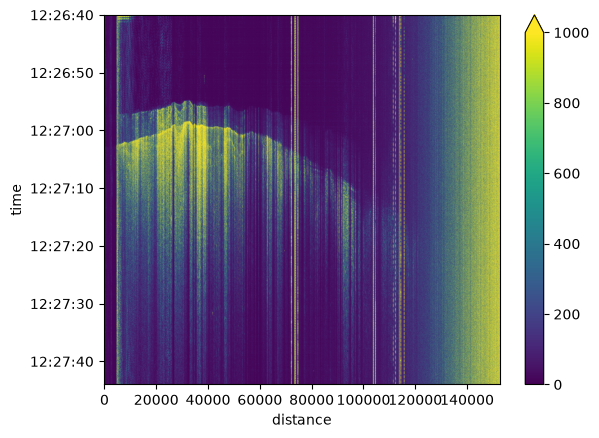

In [2]:
da = xd.open("outputs/event.nc")
dx = xd.get_sampling_interval(da, "distance")


def process(da):
    da = xd.decimate(da, 1 / (2 * dx), dim="distance")
    da = xd.filter(da, (1.0, None), ftype="iir", order=4, dim="time")
    return np.abs(da)


monolithic = process(da)
monolithic.plot(yincrease=False, vmin=0, vmax=1e3, interpolation="antialiased")

To get the pipeline behind it, call the same functions with `...` in place of
the data. Each one then returns its atom instead of applying it, and `>>`
chains them:

In [4]:
pipeline = process(...)
pipeline

Sequence:
  0: 
    Decimate(target=0.03263813483482185, window=('kaiser', 5.0), dim=distance)
      FIRFilter(numtaps=Ellipsis, cutoff=Ellipsis, btype=lowpass, window=('kaiser', 5.0), scale=True, up=1, down=1, dim=distance)
  1: 
    Filter(freq=(1.0, None), ftype=iir, order=4, zerophase=False, dim=time, btype=highpass, cutoff=1.0)
      IIRFilter(order=4, cutoff=1.0, btype=highpass, ftype=butter, stype=sos, dim=time)
  2: absolute(...)

In [ ]:
pipeline = (
    xd.decimate(..., 1 / (2 * dx), dim="distance") 
    >> xd.filter(..., (1.0, None), ftype="iir", order=4, dim="time")
    >> np.abs
)
pipeline

Sequence:
  0: 
    Decimate(target=0.03263813483482185, window=('kaiser', 5.0), dim=distance)
      FIRFilter(numtaps=Ellipsis, cutoff=Ellipsis, btype=lowpass, window=('kaiser', 5.0), scale=True, up=1, down=1, dim=distance)
  1: 
    Filter(freq=(1.0, None), ftype=iir, order=4, zerophase=False, dim=time, btype=highpass, cutoff=1.0)
      IIRFilter(order=4, cutoff=1.0, btype=highpass, ftype=butter, stype=sos, dim=time)
  2: <lambda>(...)

Note the last line: under the seed, an ordinary numpy call does not compute
anything, it appends itself to the pipeline. So the pipeline reads like the
function it replaces.

The result is a callable, and on a whole array it gives exactly what the
function gave:

In [10]:
pipeline = xa.Sequential([
    xd.decimate(..., 1 / (2 * dx), dim="distance"),
    xd.filter(..., (1.0, None), ftype="iir", order=4, dim="time"),
    np.abs
])
pipeline

NameError: name 'xa' is not defined

In [4]:
atomic = pipeline(da)
assert atomic.equals(monolithic)

## Running it chunk by chunk

`process` runs the same pipeline over a source it cuts into chunks. Here the
array is cut every 1000 samples along time:

In [5]:
chunked = pipeline.process(da, chunks={"time": 1000})
assert chunked.equals(monolithic)


  0%|          | 0.00/76.3M [00:00<?, ?B/s]


 25%|██▌       | 19.1M/76.3M [00:00<00:00, 106MB/s]


 25%|██▌       | 19.1M/76.3M [00:00<00:00, 106MB/s, read=7.1%, proc=92.9%, write=0.0%]


 50%|█████     | 38.1M/76.3M [00:00<00:00, 118MB/s, read=7.1%, proc=92.9%, write=0.0%]


 50%|█████     | 38.1M/76.3M [00:00<00:00, 118MB/s, read=0.7%, proc=99.3%, write=0.0%]

...


 75%|███████▌  | 57.2M/76.3M [00:00<00:00, 122MB/s, read=0.7%, proc=99.3%, write=0.0%]


100%|██████████| 76.3M/76.3M [00:00<00:00, 128MB/s, read=0.7%, proc=99.3%, write=0.0%]


100%|██████████| 76.3M/76.3M [00:00<00:00, 128MB/s, read=0.0%, proc=100.0%, write=0.0%]


100%|██████████| 76.3M/76.3M [00:00<00:00, 128MB/s, read=2.4%, proc=97.6%, write=0.0%] 


100%|██████████| 76.3M/76.3M [00:00<00:00, 123MB/s, read=2.4%, proc=97.6%, write=0.0%]

Bit for bit the same result — that is the property the whole design is for.
The highpass above is recursive: it *does* depend on the history of the
signal, and it is only identical because the atom carried its state from one
chunk to the next. At a genuine gap, where there is no history to carry, it
is flushed and restarted instead.

You can assert that property on a pipeline of your own, including across
gaps:

In [6]:
xd.testing.assert_chunk_invariant(pipeline, da, chunks={"time": 1000})

## Sources and sinks

`process` infers both ends. The source can be an array, a path or a glob, a
collection, a directory being watched, or a ZeroMQ address; the sink is
chosen from `out`: nothing for a result in memory, a directory to stream data
arrays to disk, a `.csv` for a table, an address to publish.

So the pipeline you just tested applies to the whole archive by changing the
two ends and nothing else:

In [7]:
!rm -rf outputs/chunks

In [8]:
chunked = pipeline.process(da, out="outputs/chunks", chunks={"time": 1000})
chunked


  0%|          | 0.00/76.3M [00:00<?, ?B/s]


 25%|██▌       | 19.1M/76.3M [00:00<00:00, 112MB/s]


 25%|██▌       | 19.1M/76.3M [00:00<00:00, 112MB/s, read=10.4%, proc=88.1%, write=1.5%]


 50%|█████     | 38.1M/76.3M [00:00<00:00, 119MB/s, read=10.4%, proc=88.1%, write=1.5%]


 50%|█████     | 38.1M/76.3M [00:00<00:00, 119MB/s, read=2.1%, proc=96.6%, write=1.3%] 

...


100%|██████████| 76.3M/76.3M [00:00<00:00, 129MB/s, read=3.5%, proc=95.2%, write=1.3%]


100%|██████████| 76.3M/76.3M [00:00<00:00, 129MB/s, read=0.0%, proc=98.6%, write=1.4%]


100%|██████████| 76.3M/76.3M [00:00<00:00, 129MB/s, read=4.3%, proc=94.3%, write=1.4%]


100%|██████████| 76.3M/76.3M [00:00<00:00, 123MB/s, read=4.3%, proc=94.3%, write=1.4%]

<xdas.DataArray (time: 4000, distance: 5000)>
VirtualStack: 152.6MB (float64)
Coordinates:
  * distance (distance): -306.390 to 152858.000
  * time (time): 2023-11-03T12:26:40.008 to 2023-11-03T12:27:43.992

The directory holds one file per chunk, and what comes back is a single
virtual array over all of them:

In [9]:
!ls outputs/chunks

000000000  000000001  000000002  000000003


In [10]:
assert chunked.equals(monolithic)

```{note}
Asking for a result in memory that would not fit is refused rather than
attempted: `process` checks the accumulated size against the
`"memory_limit"` configuration entry, a quarter of the machine's memory by
default.
```

## Picking phases on a large dataset

Machine-learning pickers are the same kind of problem — a model that wants
fixed-length windows, applied to something far longer. `xd.pick` wraps the
whole chain: it reads the weight set to find the rate the model expects,
resamples to it, runs the model with the window overlap and blinding it
declares, and triggers on the resulting probabilities.

In [11]:
from seisbench.models import PhaseNet

model = PhaseNet.from_pretrained("diting")
model.labels  # noise, P, S

'NPS'

In [ ]:
da = xd.open("outputs/singlecable.nc")
da = da.sel(time=slice("2023-11-03T12:26:00", "2023-11-03T12:28:00"))
da = da.sel(distance=slice(30_000, 60_000))

picks = xd.pick(da, model, thresh={"P": 0.3, "S": 0.3}, device="cpu")
picks

,distance,phase,time,value
0,30010.906106,P,2023-11-03 12:26:55.168,0.929854
1,30010.906106,S,2023-11-03 12:26:59.728,0.639718
2,30026.225609,P,2023-11-03 12:26:55.068,0.774744
3,30026.225609,S,2023-11-03 12:26:59.808,0.382613
4,30041.545112,P,2023-11-03 12:26:55.168,0.848476
...,...,...,...,...
3932,59960.534200,S,2023-11-03 12:27:00.368,0.786946
3933,59975.853703,P,2023-11-03 12:26:56.268,0.673975
3934,59975.853703,S,2023-11-03 12:27:00.428,0.860457
3935,59991.173206,P,2023-11-03 12:26:56.188,0.815888


The threshold is given per phase, which is also how the noise class gets
dropped — it is simply never asked for. Select phases by *name*: the label
order differs from one weight set to the next, so a position would be a bug
waiting to happen.

For a real archive, the same thing in atom form, streaming its table straight
to a CSV file:

In [13]:
!rm -f outputs/picks.csv

In [14]:
from xdas.atoms import Picker

picker = Picker(model, thresh={"P": 0.3, "S": 0.3}, device="cpu")
picks = picker.process(da, out="outputs/picks.csv", chunks={"time": 3750})


  0%|          | 0.00/28.0M [00:00<?, ?B/s]


 50%|█████     | 14.0M/28.0M [00:00<00:00, 48.8MB/s]


 50%|█████     | 14.0M/28.0M [00:00<00:00, 48.8MB/s, read=8.3%, proc=91.7%, write=0.0%]


100%|██████████| 28.0M/28.0M [00:04<00:00, 5.36MB/s, read=8.3%, proc=91.7%, write=0.0%]


100%|██████████| 28.0M/28.0M [00:04<00:00, 5.36MB/s, read=0.0%, proc=99.9%, write=0.1%]


100%|██████████| 28.0M/28.0M [00:07<00:00, 5.36MB/s, read=0.5%, proc=99.4%, write=0.0%]


100%|██████████| 28.0M/28.0M [00:07<00:00, 4.18MB/s, read=0.5%, proc=99.4%, write=0.0%]

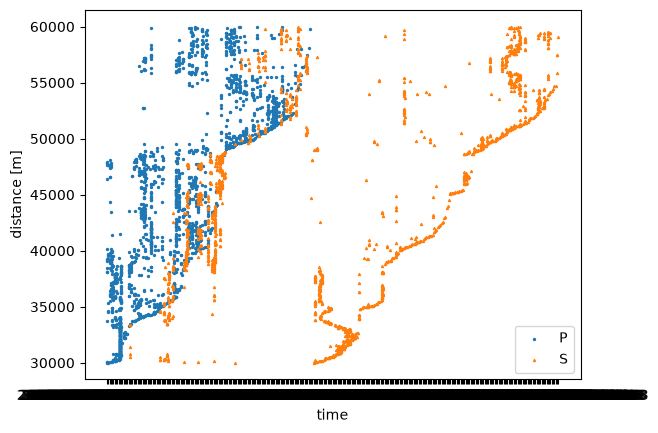

In [15]:
import matplotlib.pyplot as plt

for phase, marker in [("P", "o"), ("S", "^")]:
    sub = picks[picks["phase"] == phase]
    plt.scatter(sub["time"], sub["distance"], s=2, marker=marker, label=phase)

plt.legend()
plt.xlabel("time")
plt.ylabel("distance [m]")
plt.show()

Two moveouts, converging near 40 km along the cable: the P and S arrivals of
a regional earthquake. The next notebook turns them into a located event.